In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Student_Projects.zip to Student_Projects.zip


In [ ]:
import zipfile
import os

with zipfile.ZipFile("Student_Projects.zip", 'r') as zip_ref:
    zip_ref.extractall("project")

print("Files inside project folder:")
print(os.listdir("project"))


Files inside project folder:
['CELOSIA ARGENTEA L', 'PURPLE CHLORIS', 'CROWFOOT GRASS']


In [ ]:
import os
os.chdir("project")

print("Current files:", os.listdir())



Current files: ['CELOSIA ARGENTEA L', 'PURPLE CHLORIS', 'CROWFOOT GRASS']


In [ ]:
!pip install scikit-learn-intelex intel-extension-for-pytorch intel-tensorflow



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 14.4 MB/s eta 0:00:00


In [ ]:
from sklearnex import patch_sklearn
patch_sklearn()

print("Intel optimization enabled ✅")


Intel optimization enabled ✅


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [17]:
import tensorflow as tf

In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))


Accuracy: 0.9210526315789473


In [15]:
import os
print(os.listdir("/content/project"))


['CELOSIA ARGENTEA L', 'PURPLE CHLORIS', 'CROWFOOT GRASS']


In [18]:
DATASET_PATH = "/content/project"
IMG_SIZE = (224, 224)  # Common image size for models like MobileNet or ResNet
BATCH_SIZE = 32 # A common batch size for training

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 193 files belonging to 3 classes.
Using 155 files for training.
Found 193 files belonging to 3 classes.
Using 38 files for validation.


In [19]:
print(train_ds.class_names)


['CELOSIA ARGENTEA L', 'CROWFOOT GRASS', 'PURPLE CHLORIS']


In [80]:
num_classes = len(train_ds.class_names)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)), # Explicitly define the input layer
    tf.keras.layers.Rescaling(1./255), # Rescaling layer no longer needs input_shape
    tf.keras.layers.Conv2D(16, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

model.build((None, 224, 224, 3))


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.3097 - loss: 1.2981 - val_accuracy: 0.5526 - val_loss: 1.0539
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.4581 - loss: 1.1057 - val_accuracy: 0.3158 - val_loss: 1.1445
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.4774 - loss: 1.0127 - val_accuracy: 0.4211 - val_loss: 1.1107
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.5290 - loss: 0.9190 - val_accuracy: 0.5263 - val_loss: 1.0101
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step - accuracy: 0.6774 - loss: 0.8362 - val_accuracy: 0.5000 - val_loss: 0.9759
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7419 - loss: 0.7218 - val_accuracy: 0.5000 - val_loss: 0.8938
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.7226 - loss: 0.6563 - val_accuracy: 0.5526 - val_loss: 0.9022
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.7613 - loss: 0.5857 - val_accuracy: 0.4474 - val_loss: 1.4653
Epoch 9/1

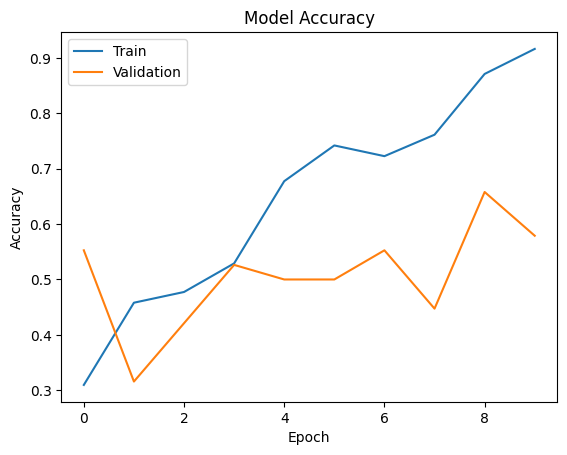

In [81]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])

plt.show()


In [82]:
model.save("plant_model.keras")


In [69]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,685,675 (63.65 MB)

 Trainable params: 5,561,891 (21.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,123,784 (42.43 MB)

In [83]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "kk.jpeg"

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

predicted_class = train_ds.class_names[np.argmax(prediction)]

print("🌿 Predicted Plant:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
🌿 Predicted Plant: PURPLE CHLORIS


In [84]:
PLANT_DATABASE = {
    "CROWFOOT GRASS": {
        "type": "Weed",
        "risk": "High",
        "advice": "Remove early",
        "reason": "This weed competes with crops for nutrients and can reduce yield significantly."
    },
    "PURPLE CHLORIS": {
        "type": "Weed",
        "risk": "High",
        "advice": "Control spread",
        "reason": "It spreads quickly and can dominate farmland, affecting crop growth."
    },
    "CELOSIA ARGENTEA L": {
        "type": "Useful Plant",
        "risk": "Low",
        "advice": "Safe to keep",
        "reason": "This plant is beneficial and does not harm crops; it may even have medicinal value."
    }
}

print("\n🌿 Predicted Plant:", predicted_class)

info = PLANT_DATABASE.get(predicted_class.upper(), None)

if info:
    print("📌 Type:", info["type"])
    print("⚠ Risk:", info["risk"])
    print("💡 Advice:", info["advice"])
    print("❓ Why it matters:", info["reason"])



🌿 Predicted Plant: PURPLE CHLORIS
📌 Type: Weed
⚠ Risk: High
💡 Advice: Control spread
❓ Why it matters: It spreads quickly and can dominate farmland, affecting crop growth.


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

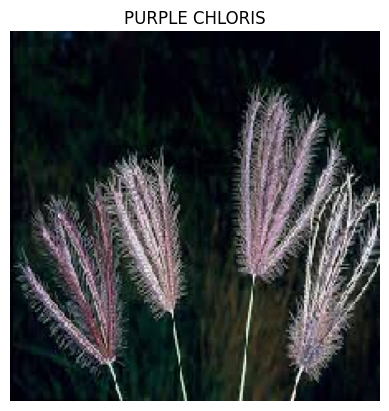

In [85]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(predicted_class)
plt.axis('off')


In [94]:
import tensorflow as tf
import cv2
def get_gradcam_heatmap(model, img_array, last_conv_layer_name):

    import tensorflow as tf

    img_array = tf.cast(img_array, tf.float32)

    # 🔥 Create new input
    inputs = tf.keras.Input(shape=(224, 224, 3))

    x = inputs
    last_conv_output = None

    # Forward pass manually
    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            last_conv_output = x

    # New model output
    preds = x

    # Build grad model
    grad_model = tf.keras.models.Model(inputs=inputs, outputs=[last_conv_output, preds])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()




In [95]:
for layer in model.layers:
    if "conv2d" in layer.name:
        print(layer.name)


conv2d_9
conv2d_10
conv2d_11


In [97]:
img = cv2.imread("kk.jpeg")
img = cv2.resize(img, (224, 224))

img_array = np.expand_dims(img, axis=0) / 255.0

heatmap = get_gradcam_heatmap(model, img_array, "conv2d_11")


In [25]:
from google.colab import files
files.upload()


Saving kk.jpeg to kk.jpeg


{'kk.jpeg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00\x84\x00\t\x06\x07\x13\x13\x12\x15\x13\x13\x12\x15\x15\x15\x15\x18\x18\x1a\x18\x17\x17\x18\x17\x17\x17\x18\x1a\x18\x1d\x1a\x18\x17\x17\x17\x17\x18\x1d( \x18\x1d%\x1d\x17\x15!1!%)+...\x17\x1f383-7(-.+\x01\n\n\n\x0e\r\x0e\x1a\x10\x10\x1b-% %--------------------------------------------------\xff\xc0\x00\x11\x08\x00\xb7\x01\x13\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1b\x00\x00\x01\x05\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x03\x00\x02\x04\x05\x06\x01\x07\xff\xc4\x00C\x10\x00\x02\x01\x03\x03\x02\x04\x04\x04\x03\x04\x08\x05\x05\x00\x00\x01\x02\x11\x00\x03!\x04\x121\x05A\x06\x13"Q2aq\x81#B\x91\xa1\x14R\x823Cb\xf0\x07Scr\xa2\xb1\xb2\xc1\x15\x92\xd1\xe1\xf1$s\xa3\xb3\xc2\xff\xc4\x00\x19\x01\x00\x03\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\xff\xc4\x00&\x11\x00\x02\x02\x02\x02\x02\x03\x00\x01\x05\x00\x00\x00\x00\x00\x00\x00\x01\x02\x11!1\x12A

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


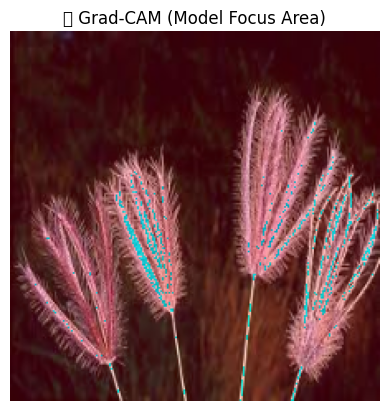

In [98]:
# Resize heatmap
heatmap = cv2.resize(heatmap, (224, 224))
heatmap = np.uint8(255 * heatmap)

# Apply color map (red = important)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Overlay on original image
original_img = cv2.imread("kk.jpeg")
original_img = cv2.resize(original_img, (224, 224))

superimposed_img = heatmap * 0.4 + original_img

# Show result
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.title("🔥 Grad-CAM (Model Focus Area)")
plt.axis('off')
plt.show()


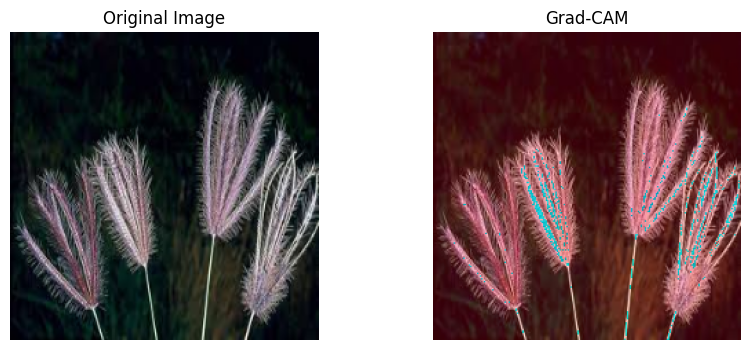

In [99]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM")
plt.axis('off')

plt.show()


In [100]:
cv2.imwrite("gradcam_result.jpg", superimposed_img)


True

In [101]:
model.save("plant_model.keras")


In [104]:
from google.colab import files
files.download("plant_model.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>